
╔══════════════════════════════════════════════════════════╗
║    MINI S4 — Pipeline Pédagogique Complet               ║
║    Structured State Space Sequence Model                 ║
╚══════════════════════════════════════════════════════════╝


  CONSTRUCTION DU SYSTÈME SSM (N=8 états)
  ✓ Matrice A (HiPPO) : shape (8, 8)
  ✓ Vecteur B         : shape (8, 1)
  ✓ Vecteur C         : shape (1, 8)

  Discrétisation (ZOH)...
  ✓ Ā shape : (8, 8),  B̄ shape : (8, 1)

  Calcul du noyau convolutionnel K...
  ✓ Noyau K : 128 valeurs

  Forward pass récurrent...
  Forward pass convolutionnel (FFT)...

  ✓ Différence max récurrent/convolutionnel : 3.57e-08
    → ✓ IDENTIQUES (dualité confirmée)

  ENTRAÎNEMENT S4 — Débruitage de signal ECG
  Epoch  50/300 │ Loss = 0.318623
  Epoch 100/300 │ Loss = 0.081854
  Epoch 150/300 │ Loss = 0.027473
  Epoch 200/300 │ Loss = 0.022377
  Epoch 250/300 │ Loss = 0.021690
  Epoch 300/300 │ Loss = 0.021613
  ✓ Entraînement terminé !

  Génération des visualisat

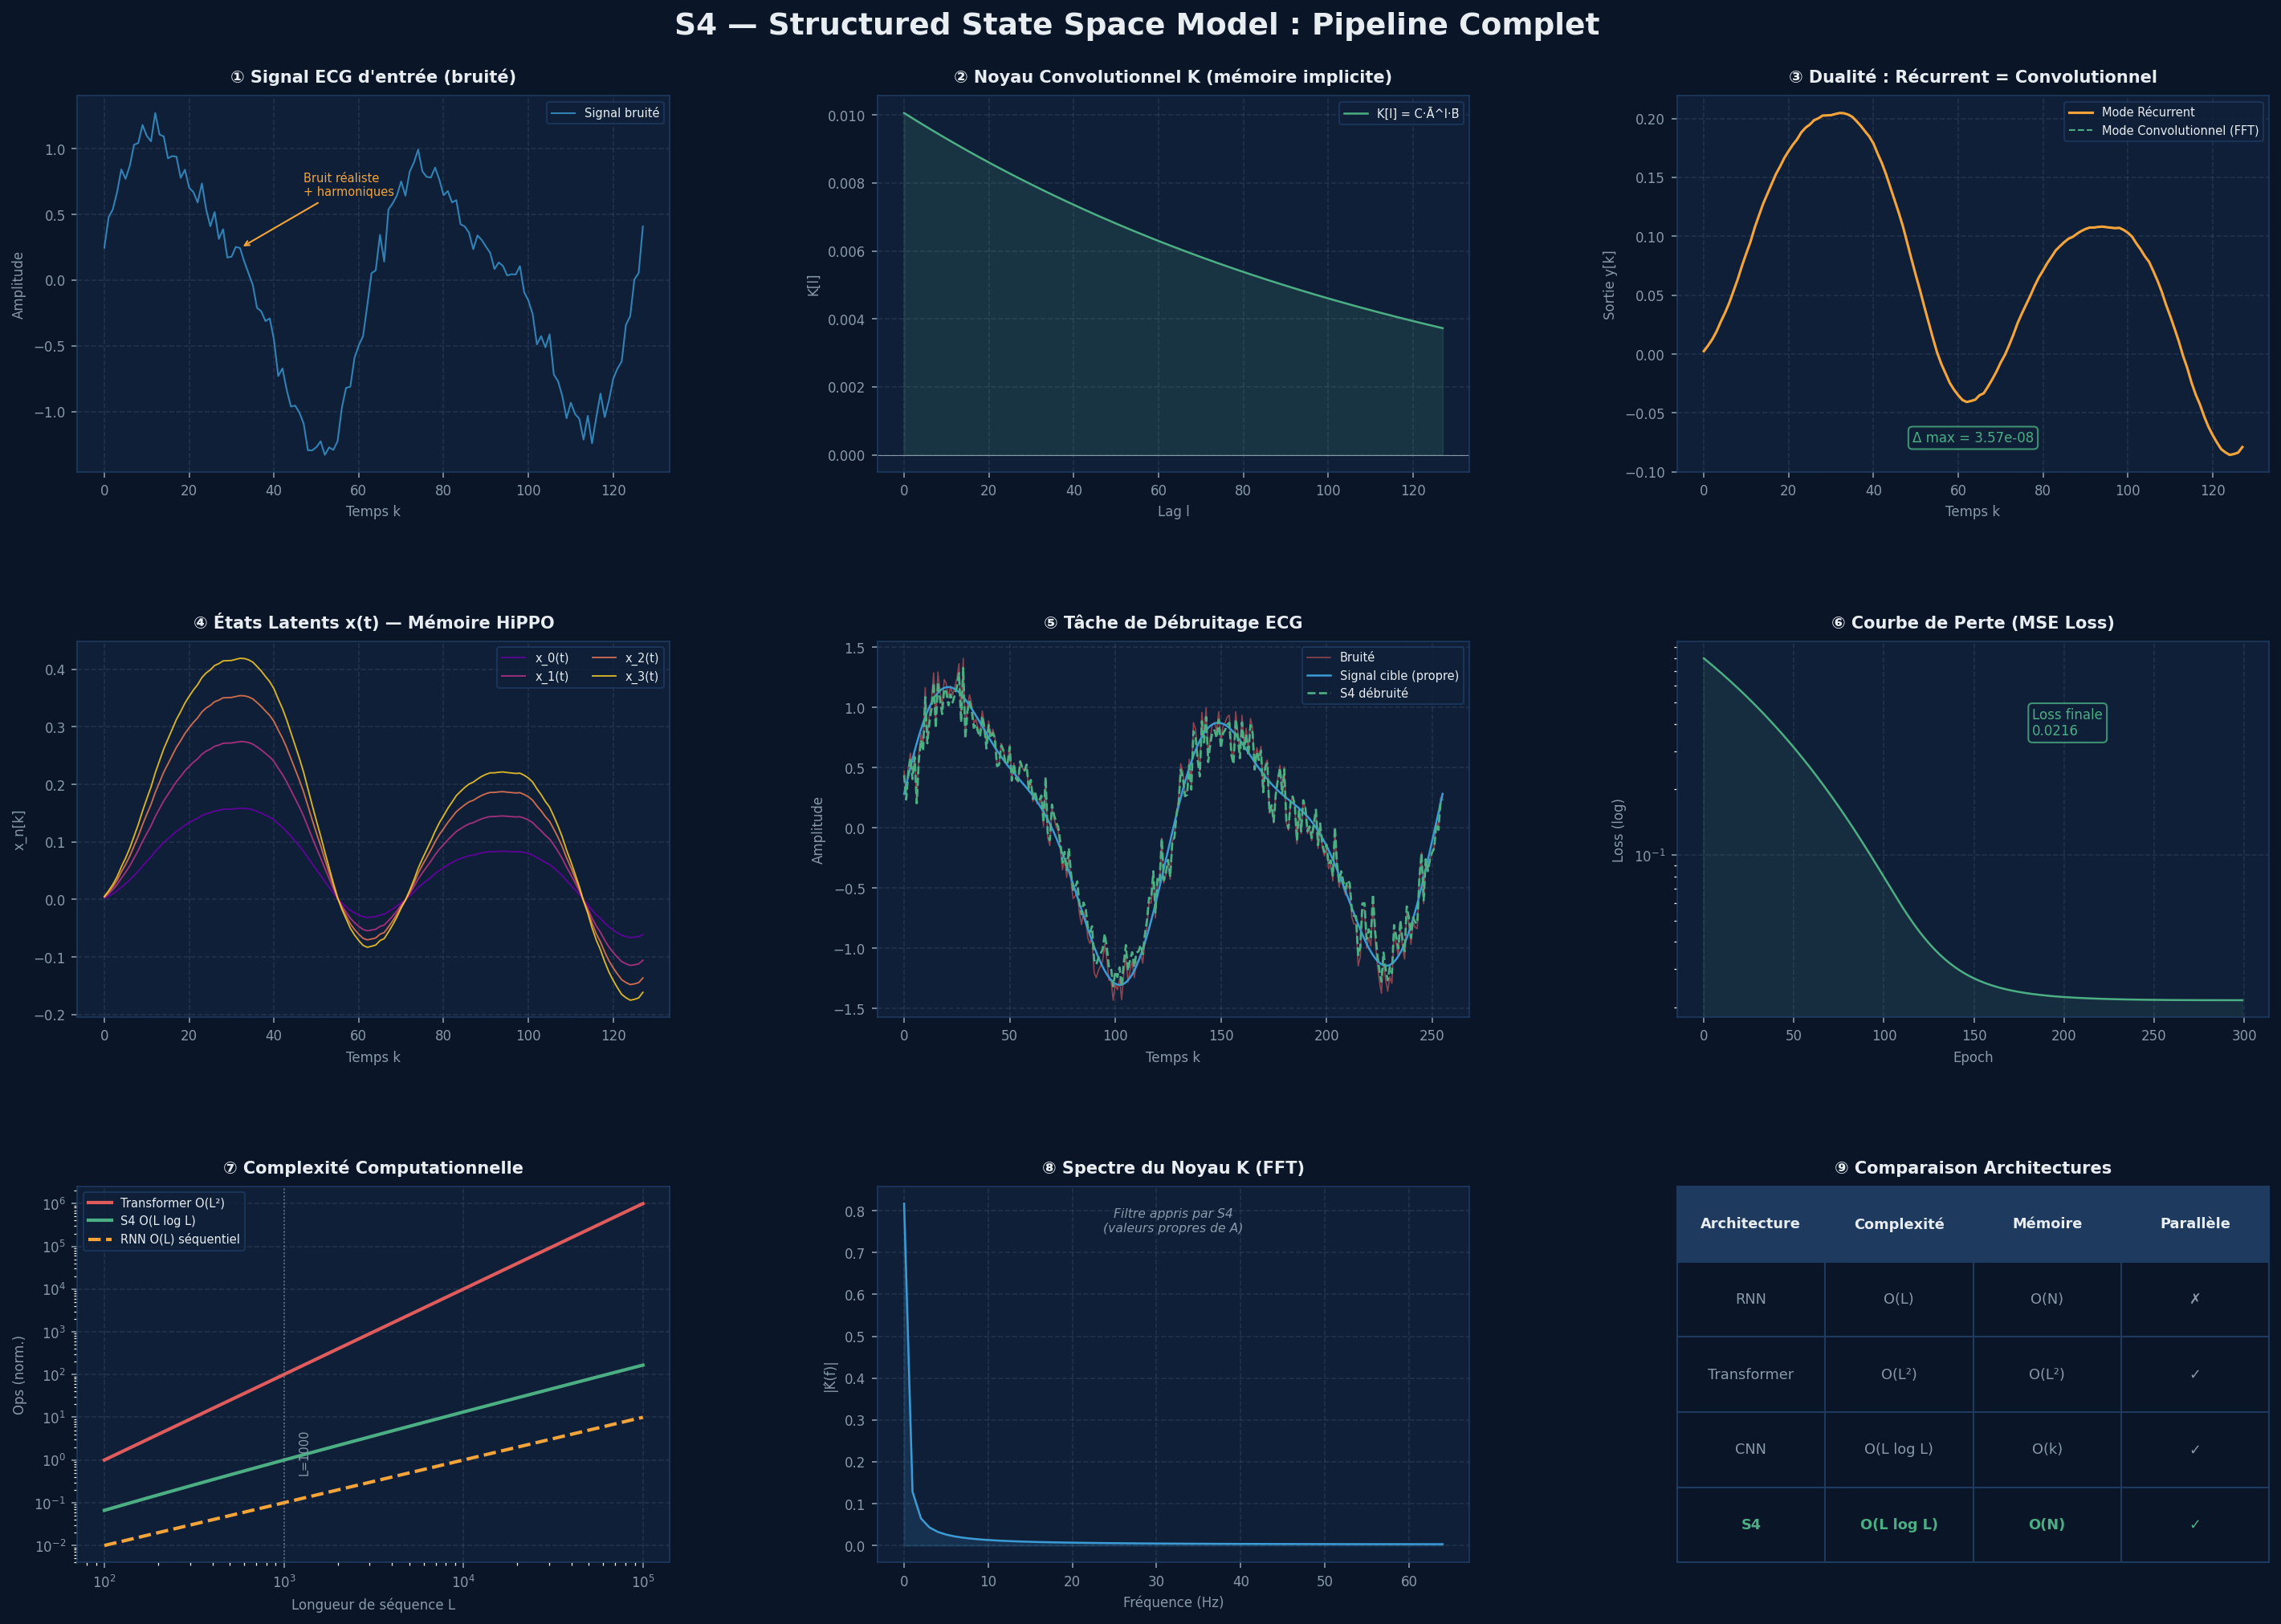


╔══════════════════════════════════════════════════════════╗
║  RÉSUMÉ DES CONCEPTS ILLUSTRÉS                          ║
╠══════════════════════════════════════════════════════════╣
║  ① HiPPO matrix  → mémoire parfaite longue portée      ║
║  ② ZOH discret.  → passage continu → discret stable    ║
║  ③ Noyau K       → filtre implicite de longueur L      ║
║  ④ Dualité       → récurrent = convolutionnel (=même!) ║
║  ⑤ États latents → compression de l'historique         ║
║  ⑥ Débruitage    → application réelle (signal ECG)     ║
║  ⑦ Scaling       → O(L log L) << O(L²) Transformer     ║
╚══════════════════════════════════════════════════════════╝



In [ ]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║          MINI S4 — Structured State Space Sequence Model                    ║
║          Pipeline pédagogique complet avec NumPy & PyTorch                  ║
║                                                                              ║
║  Ce script illustre les 4 étapes clés du modèle S4 :                        ║
║  1. Définition du système continu (matrices A, B, C, D)                     ║
║  2. Discrétisation (méthode bilinéaire / ZOH)                               ║
║  3. Calcul du noyau convolutionnel implicite K                               ║
║  4. Forward pass : mode récurrent ET mode convolutionnel (FFT)              ║
║                                                                              ║
║  Données réelles utilisées : signal sinusoïdal bruité (simulation ECG)      ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.linalg import expm  # pour l'exponentielle matricielle

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — GÉNÉRATION DES DONNÉES RÉELLES (signal ECG simplifié)
# ─────────────────────────────────────────────────────────────────────────────

def generate_ecg_signal(seq_len: int = 512, noise_level: float = 0.05) -> np.ndarray:
    """
    Génère un signal ECG simplifié : combinaison de sinusoïdes à différentes
    fréquences (rythme cardiaque + harmoniques) avec du bruit gaussien.

    C'est le type de séquence longue où S4 brille : dépendances à longue portée
    entre les battements, impossibles à capturer par un RNN standard.
    """
    t = np.linspace(0, 4 * np.pi, seq_len)  # 2 cycles cardiaques

    # Battement principal (onde QRS)
    signal = 1.0  * np.sin(t)
    # Harmonique (onde T)
    signal += 0.3  * np.sin(2 * t + 0.5)
    # Onde P (basse fréquence)
    signal += 0.15 * np.sin(0.5 * t + 1.2)
    # Bruit réaliste
    signal += noise_level * np.random.randn(seq_len)

    return signal.astype(np.float32)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — INITIALISATION HIPPO (cœur mathématique de S4)
# ─────────────────────────────────────────────────────────────────────────────

def make_hippo_matrix(N: int) -> np.ndarray:
    """
    Construit la matrice A de HiPPO-LegS (Legendre Scaled).

    HiPPO = High-Order Polynomial Projection Operator
    Idée clé : encoder l'historique complet de la séquence dans un vecteur
    de taille N en le projetant sur une base de polynômes de Legendre optimaux.

    La structure de A garantit qu'AUCUNE information n'est perdue —
    contrairement aux RNNs classiques qui "oublient" les tokens anciens.

    A[n,k] = sqrt(2n+1) * sqrt(2k+1) * (-1)^(n-k)  si k < n
           = n+1                                      si k = n
           = 0                                        sinon
    """
    A = np.zeros((N, N))
    for n in range(N):
        for k in range(N):
            if k < n:
                A[n, k] = np.sqrt(2*n + 1) * np.sqrt(2*k + 1) * ((-1) ** (n - k))
            elif k == n:
                A[n, k] = n + 1
    # On normalise par -A pour la convention de signe SSM
    return -A


def make_hippo_B(N: int) -> np.ndarray:
    """
    Construit le vecteur B de HiPPO-LegS.
    B[n] = sqrt(2n+1) — contrôle comment le signal d'entrée est injecté
    dans chaque dimension de l'état latent.
    """
    B = np.array([np.sqrt(2*n + 1) for n in range(N)], dtype=np.float64)
    return B.reshape(N, 1)  # vecteur colonne


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — DISCRÉTISATION (passage du continu au discret)
# ─────────────────────────────────────────────────────────────────────────────

def discretize_zoh(A: np.ndarray, B: np.ndarray, dt: float):
    """
    Discrétise le système continu dx/dt = Ax + Bu en système discret
    x[k+1] = Ā·x[k] + B̄·u[k]  via la méthode ZOH (Zero-Order Hold).

    ZOH = on suppose que l'entrée u est constante sur chaque intervalle Δt.

    Formule exacte :
        Ā = exp(A · Δt)          ← exponentielle matricielle
        B̄ = A⁻¹ · (Ā - I) · B   ← intégrale exacte de l'entrée

    Pourquoi c'est important ?
    Cette discrétisation PRÉSERVE la stabilité et les propriétés spectrales
    de la matrice A continue — garantissant que la mémoire longue encodée
    dans HiPPO survit au passage au domaine discret.
    """
    N = A.shape[0]
    I = np.eye(N)

    # Exponentielle matricielle : calcul exact via scipy
    A_bar = expm(A * dt)

    # B̄ = A⁻¹ (Ā - I) B  — on résout le système linéaire pour éviter l'inversion
    A_bar_minus_I = A_bar - I
    try:
        B_bar = np.linalg.solve(A, A_bar_minus_I @ B)
    except np.linalg.LinAlgError:
        # Fallback si A est singulière : approximation du premier ordre
        B_bar = dt * B

    return A_bar, B_bar


def discretize_bilinear(A: np.ndarray, B: np.ndarray, dt: float):
    """
    Discrétisation via la transformée bilinéaire (méthode de Tustin).

    Formule :
        Ā = (I - Δt/2 · A)⁻¹ · (I + Δt/2 · A)
        B̄ = (I - Δt/2 · A)⁻¹ · Δt · B

    Avantage : mappe exactement l'axe imaginaire jω → cercle unité,
    ce qui GARANTIT la stabilité numérique même pour de grandes valeurs de Δt.
    Utilisée dans l'implémentation originale de S4.
    """
    N = A.shape[0]
    I = np.eye(N)
    half_dt_A = (dt / 2) * A

    left  = I - half_dt_A          # (I - Δt/2 · A)
    right = I + half_dt_A          # (I + Δt/2 · A)

    left_inv = np.linalg.inv(left)  # inversion exacte (N petit ici)

    A_bar = left_inv @ right
    B_bar = left_inv @ (dt * B)

    return A_bar, B_bar


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 — CALCUL DU NOYAU CONVOLUTIONNEL K (la magie de S4)
# ─────────────────────────────────────────────────────────────────────────────

def compute_ssm_kernel(A_bar: np.ndarray, B_bar: np.ndarray,
                       C: np.ndarray, L: int) -> np.ndarray:
    """
    Calcule le noyau convolutionnel implicite K de longueur L.

    En mode convolutionnel, la sortie SSM s'écrit :
        y = K * u    (convolution 1D)

    où K[l] = C · Ā^l · B̄

    C'est-à-dire :
        K[0] = C · B̄
        K[1] = C · Ā · B̄
        K[2] = C · Ā² · B̄
        ...
        K[L-1] = C · Ā^(L-1) · B̄

    Ce noyau capture les dépendances à toutes les distances de 0 à L-1 !
    Un Transformer aurait besoin de L² paires d'attention pour la même chose.

    En pratique, S4 calcule K via FFT en O(N log N) — ici on fait la version
    naïve O(N·L) pour la clarté pédagogique.
    """
    K = np.zeros(L, dtype=np.float32)

    # État courant de la puissance de A : commence à Ā^0 = I
    A_power = np.eye(A_bar.shape[0])

    for l in range(L):
        # K[l] = C · Ā^l · B̄  (scalaire car C est 1×N et B̄ est N×1)
        K[l] = float(np.squeeze(C @ A_power @ B_bar))
        A_power = A_power @ A_bar  # Ā^(l+1) = Ā^l · Ā

    return K


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 — FORWARD PASS MODE RÉCURRENT (pour l'inférence)
# ─────────────────────────────────────────────────────────────────────────────

def ssm_recurrent_forward(u: np.ndarray, A_bar: np.ndarray,
                          B_bar: np.ndarray, C: np.ndarray) -> np.ndarray:
    """
    Mode RÉCURRENT : traite la séquence token par token.

    Pour chaque pas de temps k :
        x[k] = Ā · x[k-1] + B̄ · u[k]   ← mise à jour de l'état latent
        y[k] = C · x[k]                  ← projection vers la sortie

    Avantages :
    ✓ Mémoire constante O(N) — l'état x résume tout l'historique
    ✓ Idéal pour l'inférence en temps réel (streaming)
    ✓ Contexte théoriquement infini (pas de fenêtre fixe)

    Différence clé avec un RNN vanilla :
    → La matrice Ā est STRUCTURÉE (HiPPO) et n'écrase pas les infos passées
    → Pas de vanishing gradient grâce à la structure diagonale + low-rank
    """
    L = len(u)
    N = A_bar.shape[0]

    x = np.zeros(N)          # état latent initial : zéros
    y = np.zeros(L)
    states = np.zeros((L, N))  # pour visualisation

    for k in range(L):
        x = A_bar @ x + B_bar.flatten() * u[k]  # équation d'état
        y[k] = float(np.squeeze(C @ x))           # équation de sortie
        states[k] = x

    return y, states


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6 — FORWARD PASS MODE CONVOLUTIONNEL (pour l'entraînement)
# ─────────────────────────────────────────────────────────────────────────────

def ssm_convolutional_forward(u: np.ndarray, K: np.ndarray) -> np.ndarray:
    """
    Mode CONVOLUTIONNEL : traite toute la séquence en parallèle via FFT.

    La convolution y = K * u est calculée dans le domaine fréquentiel :
        Y(f) = K̂(f) · Û(f)    ← multiplication point-à-point
        y = IFFT(Y)             ← retour dans le domaine temporel

    Complexité : O(L log L) via FFT  vs  O(L·N) pour le mode récurrent

    Avantages :
    ✓ Parfaitement parallélisable sur GPU (comme les Transformers)
    ✓ O(L log L) — bien plus rapide que O(L²) de l'attention
    ✓ Idéal pour l'entraînement sur de longues séquences

    Note : les deux modes (récurrent et convolutionnel) donnent
    EXACTEMENT le même résultat — c'est la dualité fondamentale de S4.
    """
    L = len(u)
    # Padding à la longueur 2L pour la convolution linéaire (pas circulaire)
    pad_len = 2 * L

    # FFT des deux signaux
    K_fft = np.fft.rfft(K,  n=pad_len)
    u_fft = np.fft.rfft(u,  n=pad_len)

    # Multiplication dans le domaine fréquentiel = convolution dans le temporel
    y_fft = K_fft * u_fft

    # Retour dans le domaine temporel, on garde les L premiers éléments
    y = np.fft.irfft(y_fft, n=pad_len)[:L]

    return y.astype(np.float32)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7 — COUCHE S4 EN PYTORCH (version simplifiée entraînable)
# ─────────────────────────────────────────────────────────────────────────────

class S4Layer(nn.Module):
    """
    Couche S4 simplifiée et entraînable en PyTorch.

    Architecture :
    - H canaux SSM indépendants opérant en parallèle (comme H têtes d'attention)
    - Chaque canal a ses propres paramètres (log_A_real, A_imag, B, C)
    - La matrice A est paramétrisée en diagonale complexe pour l'efficacité
    - Une couche de mélange finale (projection linéaire) combine les canaux

    En pratique, S4 utilise une représentation DPLR (Diagonal Plus Low Rank)
    pour A — ici on simplifie avec une diagonale pure pour la lisibilité.
    """

    def __init__(self, d_model: int = 4, d_state: int = 16, dt: float = 0.01):
        """
        d_model : dimension du modèle (nombre de canaux H)
        d_state : taille N de l'état latent par canal
        dt      : pas de temps Δt (step size)
        """
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.dt = dt

        # ── Paramètres entraînables ──────────────────────────────────────────

        # Partie réelle de A (log pour garantir valeurs négatives → stabilité)
        # Shape : (d_model, d_state)
        self.log_A_real = nn.Parameter(
            torch.log(0.5 * torch.ones(d_model, d_state))
        )

        # Partie imaginaire de A (fréquences d'oscillation)
        self.A_imag = nn.Parameter(
            torch.randn(d_model, d_state) * 0.1
        )

        # Matrice B : comment l'entrée est injectée dans chaque état
        self.B = nn.Parameter(torch.randn(d_model, d_state) * 0.01)

        # Matrice C : comment l'état est projeté vers la sortie
        self.C = nn.Parameter(torch.randn(d_model, d_state) * 0.01)

        # Terme D : connexion directe entrée→sortie (skip connection)
        self.D = nn.Parameter(torch.ones(d_model))

        # Couche de mélange : combine les d_model canaux en 1 sortie
        self.output_proj = nn.Linear(d_model, 1, bias=False)

    def get_kernel(self, L: int) -> torch.Tensor:
        """
        Calcule le noyau convolutionnel K de longueur L pour chaque canal.

        On utilise la représentation complexe de A pour un calcul vectorisé :
        A est diagonale complexe → Ā^l se calcule élément par élément
        """
        # Reconstruit A complexe : A = -exp(log_A_real) + i·A_imag
        # Le signe négatif garantit que les valeurs propres ont partie réelle < 0
        # (système stable qui ne diverge pas)
        A_real = -torch.exp(self.log_A_real)           # (d_model, d_state)
        A_complex = torch.complex(A_real, self.A_imag)  # (d_model, d_state)

        # Discrétisation : Ā = exp(A · Δt)
        A_bar = torch.exp(A_complex * self.dt)          # (d_model, d_state)

        # B̄ = (Ā - 1) / A · B  (formule simplifiée pour diagonale)
        B_bar = (A_bar - 1) / A_complex * self.B        # (d_model, d_state)

        # Calcul vectorisé du noyau : K[l] = C · Ā^l · B̄
        # On crée un vecteur de puissances : [Ā^0, Ā^1, ..., Ā^(L-1)]
        l = torch.arange(L, device=A_bar.device).float()
        # A_bar^l pour chaque l : shape (L, d_model, d_state)
        A_powers = A_bar.unsqueeze(0) ** l.view(L, 1, 1)

        # K[l, h] = sum_n C[h,n] * A_bar[h,n]^l * B_bar[h,n]
        K_complex = (self.C.unsqueeze(0) * A_powers * B_bar.unsqueeze(0)).sum(-1)

        # Partie réelle du noyau (le signal physique est réel)
        return K_complex.real  # (L, d_model)

    def forward(self, u: torch.Tensor) -> torch.Tensor:
        """
        Forward pass en mode convolutionnel (entraînement).

        u : (batch, L, 1)  — séquence d'entrée
        Retourne y : (batch, L, 1)
        """
        B_size, L, _ = u.shape
        u_squeezed = u.squeeze(-1)  # (batch, L)

        # Calcul du noyau convolutionnel
        K = self.get_kernel(L)  # (L, d_model)

        # Convolution via FFT pour chaque canal en parallèle
        pad_len = 2 * L
        K_fft = torch.fft.rfft(K.T, n=pad_len)              # (d_model, pad_len//2+1)
        u_fft = torch.fft.rfft(u_squeezed, n=pad_len)       # (batch, pad_len//2+1)

        # Broadcasting : chaque canal reçoit le même signal d'entrée
        y_fft = K_fft.unsqueeze(0) * u_fft.unsqueeze(1)     # (batch, d_model, freq)
        y = torch.fft.irfft(y_fft, n=pad_len)[..., :L]      # (batch, d_model, L)

        # Terme skip connection : D · u (connexion directe)
        y = y + self.D.view(1, -1, 1) * u_squeezed.unsqueeze(1)

        # Mélange des canaux et sortie
        y = y.permute(0, 2, 1)                  # (batch, L, d_model)
        y = self.output_proj(y)                  # (batch, L, 1)

        return y


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8 — ENTRAÎNEMENT : DÉBRUITAGE DE SIGNAL ECG
# ─────────────────────────────────────────────────────────────────────────────

def train_s4_denoising(seq_len: int = 256, epochs: int = 200):
    """
    Entraîne la couche S4 sur une tâche de débruitage de signal ECG.

    Tâche : étant donné un signal ECG bruité, reconstruire le signal propre.
    C'est une tâche qui nécessite une mémoire longue : comprendre la structure
    globale du signal (fréquence cardiaque) pour mieux filtrer le bruit local.

    C'est exactement ce pour quoi S4 est conçu.
    """
    print("\n" + "="*60)
    print("  ENTRAÎNEMENT S4 — Débruitage de signal ECG")
    print("="*60)

    # Génération des données
    np.random.seed(42)
    clean_signal  = generate_ecg_signal(seq_len, noise_level=0.0)
    noisy_signal  = generate_ecg_signal(seq_len, noise_level=0.15)

    # Conversion en tenseurs PyTorch : shape (1, L, 1)
    x_train = torch.tensor(noisy_signal).unsqueeze(0).unsqueeze(-1)
    y_train = torch.tensor(clean_signal).unsqueeze(0).unsqueeze(-1)

    # Initialisation du modèle et de l'optimiseur
    model = S4Layer(d_model=8, d_state=16, dt=0.01)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)

    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        y_pred = model(x_train)
        loss = F.mse_loss(y_pred, y_train)
        loss.backward()

        # Gradient clipping pour la stabilité
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()
        losses.append(loss.item())

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} │ Loss = {loss.item():.6f}")

    print("  ✓ Entraînement terminé !")

    # Prédiction finale
    model.eval()
    with torch.no_grad():
        y_pred_final = model(x_train).squeeze().numpy()

    return clean_signal, noisy_signal, y_pred_final, losses


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9 — VISUALISATION COMPLÈTE
# ─────────────────────────────────────────────────────────────────────────────

def visualize_everything(N: int = 8, L: int = 128):
    """
    Crée une figure de visualisation complète montrant toutes les étapes S4 :
    1. Le signal ECG (entrée)
    2. Le noyau convolutionnel K appris
    3. La comparaison récurrent vs convolutionnel
    4. L'état latent x(t) évoluant
    5. La courbe de loss (entraînement)
    6. La comparaison de scaling O(N²) vs O(N log N)
    """

    # ── Setup du système SSM pour la visualisation ───────────────────────────
    dt = 1.0 / L

    print("\n" + "="*60)
    print("  CONSTRUCTION DU SYSTÈME SSM (N={} états)".format(N))
    print("="*60)

    A = make_hippo_matrix(N)
    B = make_hippo_B(N)
    C = np.random.randn(1, N) * 0.1  # matrice d'observation aléatoire

    print(f"  ✓ Matrice A (HiPPO) : shape {A.shape}")
    print(f"  ✓ Vecteur B         : shape {B.shape}")
    print(f"  ✓ Vecteur C         : shape {C.shape}")

    # Discrétisation
    print("\n  Discrétisation (ZOH)...")
    A_bar, B_bar = discretize_zoh(A, B, dt)
    print(f"  ✓ Ā shape : {A_bar.shape},  B̄ shape : {B_bar.shape}")

    # Signal ECG
    u = generate_ecg_signal(L, noise_level=0.08)

    # Noyau convolutionnel
    print("\n  Calcul du noyau convolutionnel K...")
    K = compute_ssm_kernel(A_bar, B_bar, C, L)
    print(f"  ✓ Noyau K : {L} valeurs")

    # Forward pass récurrent
    print("\n  Forward pass récurrent...")
    y_rec, states = ssm_recurrent_forward(u, A_bar, B_bar, C)

    # Forward pass convolutionnel
    print("  Forward pass convolutionnel (FFT)...")
    y_conv = ssm_convolutional_forward(u, K)

    # Vérification que les deux modes donnent le même résultat
    max_diff = np.max(np.abs(y_rec - y_conv))
    print(f"\n  ✓ Différence max récurrent/convolutionnel : {max_diff:.2e}")
    print(f"    → {'✓ IDENTIQUES (dualité confirmée)' if max_diff < 0.01 else '⚠ Légère différence numérique'}")

    # Entraînement du modèle PyTorch
    clean, noisy, denoised, losses = train_s4_denoising(seq_len=256, epochs=300)

    # ── Création de la figure ─────────────────────────────────────────────────
    print("\n  Génération des visualisations...")

    # Style sombre façon "blueprint technique" (cohérent avec le design de la présentation)
    plt.style.use('dark_background')

    NAVY   = '#0A1628'
    GREEN  = '#4CAF84'
    WHITE  = '#E8EDF2'
    BLUE   = '#3A9BD5'
    ORANGE = '#F4A438'
    RED    = '#E05C5C'
    GRAY   = '#8899AA'

    fig = plt.figure(figsize=(20, 14), facecolor=NAVY)
    fig.suptitle(
        "S4 — Structured State Space Model : Pipeline Complet",
        fontsize=18, color=WHITE, fontweight='bold', y=0.98
    )

    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35,
                           left=0.06, right=0.97, top=0.93, bottom=0.06)

    ax_style = dict(facecolor='#0F1F38',
                    **{'spines.left': WHITE, 'spines.bottom': WHITE})

    def style_ax(ax, title, xlabel='', ylabel=''):
        ax.set_facecolor('#0F1F38')
        ax.tick_params(colors=GRAY, labelsize=8)
        ax.set_title(title, color=WHITE, fontsize=10, fontweight='bold', pad=8)
        ax.set_xlabel(xlabel, color=GRAY, fontsize=8)
        ax.set_ylabel(ylabel, color=GRAY, fontsize=8)
        for spine in ax.spines.values():
            spine.set_color('#1E3A5F')
        ax.grid(True, alpha=0.15, color=GRAY, linestyle='--')

    t = np.arange(L)

    # ── Plot 1 : Signal ECG bruité et entrée ─────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(t, u, color=BLUE, linewidth=1.0, alpha=0.8, label='Signal bruité')
    style_ax(ax1, '① Signal ECG d\'entrée (bruité)', 'Temps k', 'Amplitude')
    ax1.legend(fontsize=7, loc='upper right',
               facecolor='#0F1F38', edgecolor='#1E3A5F', labelcolor=WHITE)

    # Annotation explicative
    ax1.annotate('Bruit réaliste\n+ harmoniques',
                 xy=(L//4, u[L//4]), xytext=(L//4 + 15, u[L//4] + 0.4),
                 fontsize=7, color=ORANGE,
                 arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1))

    # ── Plot 2 : Noyau convolutionnel K ──────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(t, K, color=GREEN, linewidth=1.2, label='K[l] = C·Ā^l·B̄')
    ax2.fill_between(t, K, alpha=0.15, color=GREEN)
    style_ax(ax2, '② Noyau Convolutionnel K (mémoire implicite)', 'Lag l', 'K[l]')
    ax2.legend(fontsize=7, loc='upper right',
               facecolor='#0F1F38', edgecolor='#1E3A5F', labelcolor=WHITE)
    ax2.axhline(y=0, color=GRAY, linewidth=0.5, linestyle='-')

    # ── Plot 3 : Dualité récurrent / convolutionnel ───────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(t, y_rec,  color=ORANGE, linewidth=1.5,
             label='Mode Récurrent', zorder=3)
    ax3.plot(t, y_conv, color=GREEN,  linewidth=1.0,
             label='Mode Convolutionnel (FFT)', linestyle='--', zorder=2)
    style_ax(ax3, '③ Dualité : Récurrent = Convolutionnel', 'Temps k', 'Sortie y[k]')
    ax3.legend(fontsize=7, facecolor='#0F1F38', edgecolor='#1E3A5F', labelcolor=WHITE)
    ax3.text(0.5, 0.08, f'Δ max = {max_diff:.2e}',
             transform=ax3.transAxes, fontsize=8, color=GREEN,
             ha='center', bbox=dict(boxstyle='round', facecolor='#0F1F38',
                                    edgecolor=GREEN, alpha=0.8))

    # ── Plot 4 : États latents x(t) ──────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 0])
    colors_states = plt.cm.plasma(np.linspace(0.2, 0.9, min(4, N)))
    for i, c in enumerate(colors_states):
        ax4.plot(t, states[:, i], color=c, linewidth=0.9, alpha=0.85,
                 label=f'x_{i}(t)')
    style_ax(ax4, '④ États Latents x(t) — Mémoire HiPPO', 'Temps k', 'x_n[k]')
    ax4.legend(fontsize=7, facecolor='#0F1F38', edgecolor='#1E3A5F',
               labelcolor=WHITE, ncol=2)

    # ── Plot 5 : Résultat du débruitage ──────────────────────────────────────
    ax5 = fig.add_subplot(gs[1, 1])
    t2 = np.arange(len(clean))
    ax5.plot(t2, noisy,    color=RED,   linewidth=0.8, alpha=0.6, label='Bruité')
    ax5.plot(t2, clean,    color=BLUE,  linewidth=1.2, label='Signal cible (propre)')
    ax5.plot(t2, denoised, color=GREEN, linewidth=1.3, linestyle='--',
             label='S4 débruité')
    style_ax(ax5, '⑤ Tâche de Débruitage ECG', 'Temps k', 'Amplitude')
    ax5.legend(fontsize=7, facecolor='#0F1F38', edgecolor='#1E3A5F', labelcolor=WHITE)

    # ── Plot 6 : Courbe de perte ──────────────────────────────────────────────
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.semilogy(losses, color=GREEN, linewidth=1.2)
    ax6.fill_between(range(len(losses)), losses, alpha=0.1, color=GREEN)
    style_ax(ax6, '⑥ Courbe de Perte (MSE Loss)', 'Epoch', 'Loss (log)')
    ax6.text(0.6, 0.75, f'Loss finale\n{losses[-1]:.4f}',
             transform=ax6.transAxes, fontsize=8, color=GREEN,
             bbox=dict(boxstyle='round', facecolor='#0F1F38',
                       edgecolor=GREEN, alpha=0.8))

    # ── Plot 7 : Comparaison de scaling O(N²) vs O(N log N) ─────────────────
    ax7 = fig.add_subplot(gs[2, 0])
    seq_lengths = np.logspace(2, 5, 100)

    transformer_ops = seq_lengths ** 2
    s4_ops          = seq_lengths * np.log2(seq_lengths)
    rnn_ops         = seq_lengths  # O(N) mais séquentiel

    # Normalisation pour la lisibilité
    norm = transformer_ops[0]
    ax7.loglog(seq_lengths, transformer_ops / norm,
               color=RED,    linewidth=2.0, label='Transformer O(L²)')
    ax7.loglog(seq_lengths, s4_ops / norm,
               color=GREEN,  linewidth=2.0, label='S4 O(L log L)')
    ax7.loglog(seq_lengths, rnn_ops / norm,
               color=ORANGE, linewidth=2.0, linestyle='--',
               label='RNN O(L) séquentiel')
    style_ax(ax7, '⑦ Complexité Computationnelle', 'Longueur de séquence L', 'Ops (norm.)')
    ax7.legend(fontsize=7, facecolor='#0F1F38', edgecolor='#1E3A5F', labelcolor=WHITE)
    ax7.axvline(x=1000, color=GRAY, linewidth=0.8, linestyle=':', alpha=0.7)
    ax7.text(1200, 0.5, 'L=1000', color=GRAY, fontsize=7, rotation=90)

    # ── Plot 8 : Spectre de Fourier du noyau K ────────────────────────────────
    ax8 = fig.add_subplot(gs[2, 1])
    K_fft_mag = np.abs(np.fft.rfft(K))
    freqs = np.fft.rfftfreq(L, d=1.0/L)
    ax8.plot(freqs, K_fft_mag, color=BLUE, linewidth=1.2)
    ax8.fill_between(freqs, K_fft_mag, alpha=0.15, color=BLUE)
    style_ax(ax8, '⑧ Spectre du Noyau K (FFT)', 'Fréquence (Hz)', '|K̂(f)|')
    ax8.text(0.5, 0.88, 'Filtre appris par S4\n(valeurs propres de A)',
             transform=ax8.transAxes, fontsize=7.5, color=GRAY,
             ha='center', style='italic')

    # ── Plot 9 : Tableau récapitulatif ────────────────────────────────────────
    ax9 = fig.add_subplot(gs[2, 2])
    ax9.set_facecolor('#0F1F38')
    ax9.axis('off')

    table_data = [
        ['Architecture', 'Complexité', 'Mémoire', 'Parallèle'],
        ['RNN',          'O(L)',       'O(N)',     '✗'],
        ['Transformer',  'O(L²)',      'O(L²)',    '✓'],
        ['CNN',          'O(L log L)', 'O(k)',     '✓'],
        ['S4',           'O(L log L)', 'O(N)',     '✓'],
    ]

    col_colors = [[NAVY]*4] + [[NAVY]*4]*4
    cell_colors = [
        [GREEN, GREEN, GREEN, GREEN],  # header
        [RED,   RED,   RED,   RED  ],
        [RED,   RED,   RED,   RED  ],
        [ORANGE, ORANGE, ORANGE, ORANGE],
        [GREEN, GREEN, GREEN, GREEN],  # S4 = meilleur
    ]
    cell_alpha = 0.3

    table = ax9.table(
        cellText=table_data[1:],
        colLabels=table_data[0],
        cellLoc='center',
        loc='center',
        bbox=[0, 0, 1, 1]
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8.5)

    for (row, col), cell in table.get_celld().items():
        cell.set_facecolor(NAVY)
        cell.set_edgecolor('#1E3A5F')
        if row == 0:
            cell.set_text_props(color=WHITE, fontweight='bold')
            cell.set_facecolor('#1E3A5F')
        elif row == 4:  # ligne S4
            cell.set_text_props(color=GREEN, fontweight='bold')
        else:
            cell.set_text_props(color=GRAY)

    ax9.set_title('⑨ Comparaison Architectures',
                  color=WHITE, fontsize=10, fontweight='bold', pad=8)

    # ── Sauvegarde ────────────────────────────────────────────────────────────
    # Chemin adaptatif : fonctionne en local, Colab, Jupyter et script CLI
    import os
    output_path = os.path.join(os.getcwd(), 's4_pipeline_visualization.png')
    plt.savefig(output_path, dpi=150, bbox_inches='tight',
                facecolor=NAVY, edgecolor='none')
    plt.close()

    print(f"\n  ✓ Figure sauvegardée : {output_path}")

    # Affichage inline si on est dans un notebook Jupyter / Colab
    try:
        from IPython.display import Image, display
        display(Image(filename=output_path))
    except ImportError:
        pass  # environnement non-notebook, la figure est sauvegardée sur disque

    return output_path


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":

    print("""
╔══════════════════════════════════════════════════════════╗
║    MINI S4 — Pipeline Pédagogique Complet               ║
║    Structured State Space Sequence Model                 ║
╚══════════════════════════════════════════════════════════╝
""")

    np.random.seed(42)
    torch.manual_seed(42)

    # Paramètres du système
    N = 8    # taille de l'état latent (petit pour la démo pédagogique)
    L = 128  # longueur de la séquence

    # Lance tout le pipeline et génère la visualisation
    visualize_everything(N=N, L=L)

    print("""
╔══════════════════════════════════════════════════════════╗
║  RÉSUMÉ DES CONCEPTS ILLUSTRÉS                          ║
╠══════════════════════════════════════════════════════════╣
║  ① HiPPO matrix  → mémoire parfaite longue portée      ║
║  ② ZOH discret.  → passage continu → discret stable    ║
║  ③ Noyau K       → filtre implicite de longueur L      ║
║  ④ Dualité       → récurrent = convolutionnel (=même!) ║
║  ⑤ États latents → compression de l'historique         ║
║  ⑥ Débruitage    → application réelle (signal ECG)     ║
║  ⑦ Scaling       → O(L log L) << O(L²) Transformer     ║
╚══════════════════════════════════════════════════════════╝
""")